
# End-to-End Predictive Modeling: Steam Games

## Summary
This notebook is a full **end-to-end predictive modeling workflow** for Steam game metadata. It goes from:

1. data loading and flattening,
2. cleaning and feature engineering,
3. exploratory data analysis (EDA),
4. train/test splitting,
5. model training with cross-validation,
6. final evaluation on a held-out test set.

This project aims to predict whether a game is free or not based on its attributes. Using a dataset of ~5,000 Steam games collected in August 2025, we will use game's attributes to train classification models to predict whether a game will be free or not based on the following attributes: genre, supported platforms features, developer, release year, and consumer sentiment.

## 1. Introduction

### 1.1 Background

Steam is the world's largest PC game distribution platform with over 10,000 annual releases (Statista, 2026) and around 20 million daily active users (Steam, n.d.). Developers can publish games through an open submission program letting indie and small creators show off their games to a wider audience.

User reviews allow Steam's recommendation system to suggest users with potential titles they'd be interested in.

Being able to predict whether a game will be free or not will help groups determine pricing structure target audience, and game longevity. The following groups would be particularly interested in:

* Developers making pre-launch decisions about pricing, feature scope, and genre positioning
* Publishers evaluating which projects to greenlight
* Platform researchers studying what drives quality signals in large content marketplaces

### 1.2 Research Question

Can we predict whether a Steam game will be free or not using observable game attributes available at or near launch?

Specifically, we ask:

1. What specifically are players expecting when looking at paid versus free-to-play games? (price tier, genre, platform features)
2. Can machine learning classifiers accurately distinguish free and paid games?
3. What are the significant differences between free-to-play games and paid titles?



## 1.3 Dataset Description

The dataset is the Steam 2025 5K Games Dataset:

**Source:** `steam_2025_5k-dataset-games_20250831.json.gz`
**Maintainer:** vintagedon (GitHub)
**Snapshot date:** August 31, 2025
**Format:** Gzip-compressed JSON
**Size:** ~5,000 game records

Key fields used in this analysis:
| Field | Type | Description |
|-------|------|-------------|
| `steam_appid` | integer | Unique game identifier. |
|`name` | string | Game title. |
|`is_free` | boolean | Free-to-play status |
|`price_overview` | nested dict | Current price in USD. |
|`genres` | list of dicts | Official Steam genres |
|`categories`| list of dicts | Feature flags (multiplayer, achievements, etc.) |
| `tags` | dict/list | Community-applied descriptive labels. |
| `total_positive` | integer | Number of positive reviews. |
|`total_negative` | integer | Number of negative reviews. |
|`platforms` | dict | Supported OS (Windows, Mac, Linux) |
|`release_date` | nested dict | Release date string. |
| `required_age` | integer | Age rating.|
| `developer` | list of characters | Developer studio/company. |

# 0. Package Imports and Presets
We start with importing a list of packages that will be necessary for the analysis. There are checks so that if a package is missing, the analysis will tell you. There are also a few presets so that we can ensure the models will look similar, and we set the seed to ensure reproducibility.

In [1]:

# ---- Setup ----
required_packages <- c(
  "jsonlite", "tidyverse", "lubridate", "caret", "scales",
  "patchwork", "purrr", "janitor", "pROC"
)

missing_packages <- required_packages[!vapply(required_packages, requireNamespace, logical(1), quietly = TRUE)]
if (length(missing_packages) > 0) {
  stop(
    paste0(
      "Please install these packages before running the notebook: ",
      paste(missing_packages, collapse = ", ")
    )
  )
}

invisible(lapply(required_packages, library, character.only = TRUE))

knitr::opts_chunk$set(
  echo = TRUE,
  warning = FALSE,
  message = FALSE,
  fig.width = 9,
  fig.height = 5,
  fig.align = "center"
)

set.seed(123)
cat("Libraries loaded successfully.
")


── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.0     ✔ readr     2.1.5
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.1     ✔ tibble    3.3.1
✔ lubridate 1.9.4     ✔ tidyr     1.3.2
✔ purrr     1.1.0     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter()  masks stats::filter()
✖ purrr::flatten() masks jsonlite::flatten()
✖ dplyr::lag()     masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Loading required package: lattice


Attaching package: 'caret'


The following object is masked from 'package:purrr':

    lift



Attaching package: 'scales'


The following object is masked from 'package:purrr':

    discard


The following object is masked from 'package:readr':

    col_factor



Attaching package: 'janitor'


The following objects are masked from 'package:stats':

    chisq.test, fisher.test


Type 'citat

Libraries loaded successfully.


# 1. Data Loading
First, we load in the data we want to use. We check to see whether the file exists in the user's system. We check multiple possible file paths in case different systems structure their files differently. If the check is successful, we load in the file into a variable called `df`.

The very first instance of cleaning we do is iterate through some of the nested columns. The data frame, as seen from the key fields table, hosts many different nested values. We clean up the nested columns by checking the names of the columns. If a column does not contain `app_details.data.categories`, we remove it.

At the bottom, we show the shape of the data frame and where the data is stored in the user's system.

In [2]:

# ---- Locate and load the dataset ----
possible_paths <- c(
  "data/games_sample.json",
  "./data/games_sample.json",
  "/mnt/data/games_sample.json"
)

data_path <- possible_paths[file.exists(possible_paths)][1]

if (is.na(data_path) || length(data_path) == 0) {
  stop(
    paste(
      "Could not find games_sample.json.",
      "Expected one of:",
      paste(possible_paths, collapse = ", ")
    )
  )
}

raw <- fromJSON(data_path, flatten = TRUE)

if (!"games" %in% names(raw)) {
  stop("The JSON file does not contain a top-level `games` field.")
}

df <- raw$games

# Remove stray dimensions from nested list columns if present
if ("app_details.data.categories" %in% names(df)) {
  attr(df[["app_details.data.categories"]], "dim") <- NULL
}

cat("Loaded", nrow(df), "games from", data_path, "
")
cat("Raw columns:", ncol(df), "
")


Loaded 8711 games from data/games_sample.json 
Raw columns: 137 


# 2. Cleaning and Feature Engineering
We then move onto the bulk of the cleaning and feature engineering. We first rename the columns from the default names, which are difficult to read, to a more human-readable format. It conveys more information in less characters. Then, we change the data types in multiple columns. Our target column, `is_free`, for example, is turned into the factor (categorical) data type for the machine learning portion. This type of transformation occurs in all the columns, converting them into the appropriate data type.

After transforming the columns to the appropriate data type, we choose to handle missing data by deleting them. Under 10% of the data is lost when removing the missing data, which is an acceptable tradeoff. We remove repeated games using its ID and the data is ready for exploratory analysis.

## 2. Cleaning and Feature Engineering

In [3]:

# ---- Feature engineering ----
flat_data <- df |>
  rename(
    game_id          = appid,
    game_name        = name_from_applist,
    required_age     = app_details.data.required_age,
    is_free          = app_details.data.is_free,
    game_type        = app_details.data.type,
    release_date     = app_details.data.release_date.date,
    windows_support  = app_details.data.platforms.windows,
    mac_support      = app_details.data.platforms.mac,
    linux_support    = app_details.data.platforms.linux,
    categories       = app_details.data.categories,
    dlc              = app_details.data.dlc,
    demos            = app_details.data.demos,
    developers       = app_details.data.developers,
    publishers       = app_details.data.publishers
  ) |>
  mutate(
    is_free = factor(is_free, levels = c(TRUE, FALSE), labels = c("Free", "Paid")),
    required_age = suppressWarnings(as.integer(required_age)),
    game_type = as.factor(game_type),
    release_date_parsed = suppressWarnings(mdy(release_date)),
    release_year = year(release_date_parsed),
    windows_support = as.logical(windows_support),
    mac_support = as.logical(mac_support),
    linux_support = as.logical(linux_support),
    platform_count = as.integer(replace_na(windows_support, FALSE)) +
      as.integer(replace_na(mac_support, FALSE)) +
      as.integer(replace_na(linux_support, FALSE)),
    has_dlc = map_lgl(dlc, ~ length(.x) > 0),
    has_demo = map_lgl(demos, ~ length(.x) > 0),
    category_list = map(categories, function(cat) {
      if (is.null(cat) || !is.data.frame(cat) || nrow(cat) == 0) return(character(0))
      if ("description" %in% names(cat)) return(cat$description)
      character(0)
    }),
    n_categories = map_int(category_list, length),
    developer_name = map_chr(developers, ~ if (length(.x) > 0) .x[[1]] else NA_character_),
    publisher_name = map_chr(publishers, ~ if (length(.x) > 0) .x[[1]] else NA_character_)
  )

all_cats <- flat_data |>
  select(game_id, category_list) |>
  unnest(category_list) |>
  rename(category = category_list)

top_categories <- all_cats |>
  count(category, sort = TRUE) |>
  slice_head(n = 20) |>
  pull(category)

for (cat_name in top_categories) {
  col_name <- paste0("cat_", janitor::make_clean_names(cat_name))
  flat_data[[col_name]] <- map_lgl(flat_data$category_list, ~ cat_name %in% .x)
}

cat_cols <- grep("^cat_", names(flat_data), value = TRUE)

df_model <- flat_data |>
  transmute(
    game_id,
    game_name,
    is_free,
    required_age = replace_na(required_age, 0L),
    release_year = replace_na(release_year, -1L),
    game_type = fct_explicit_na(game_type, na_level = "unknown"),
    windows_support = replace_na(windows_support, FALSE),
    mac_support = replace_na(mac_support, FALSE),
    linux_support = replace_na(linux_support, FALSE),
    platform_count,
    has_dlc = replace_na(has_dlc, FALSE),
    has_demo = replace_na(has_demo, FALSE),
    n_categories = replace_na(n_categories, 0L),
    developer_name,
    publisher_name,
    across(all_of(cat_cols), ~ replace_na(.x, FALSE))
  ) |>
  filter(!is.na(is_free)) |>
  distinct(game_id, .keep_all = TRUE)

cat("Modeling table shape:", nrow(df_model), "rows x", ncol(df_model), "columns
")
glimpse(df_model)


Warning message:
"There was 1 warning in `transmute()`.
ℹ In argument: `game_type = fct_explicit_na(game_type, na_level = "unknown")`.
Caused by warning:
! `fct_explicit_na()` was deprecated in forcats 1.0.0.
ℹ Please use `fct_na_value_to_level()` instead."


Modeling table shape: 7967 rows x 35 columns
Rows: 7,967
Columns: 35
$ game_id                        <int> 3880520, 3304010, 1733400, 974330, 1718…
$ game_name                      <chr> "Madness Demo", "Blackblade Revenant", …
$ is_free                        <fct> Free, Paid, Paid, Paid, Paid, Free, Pai…
$ required_age                   <int> 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, …
$ release_year                   <dbl> 2025, -1, 2021, 2019, -1, 2009, 2024, 2…
$ game_type                      <fct> demo, game, game, dlc, game, demo, game…
$ windows_support                <lgl> TRUE, TRUE, TRUE, TRUE, TRUE, TRUE, TRU…
$ mac_support                    <lgl> FALSE, FALSE, FALSE, TRUE, TRUE, FALSE,…
$ linux_support                  <lgl> FALSE, FALSE, FALSE, TRUE, TRUE, FALSE,…
$ platform_count                 <int> 1, 1, 1, 3, 3, 1, 1, 3, 1, 1, 1, 2, 1, …
$ has_dlc                        <lgl> FALSE, FALSE, FALSE, FALSE, FALSE, FALS…
$ has_demo                       <lgl> FALSE, FALSE

# 3. Exploratory Data Analysis (EDA)
Here, we begin exploring the processed data to look for anything that may affect the final model. Our first graph looks at the class distribution between free and paid games. We can see there is a severe class imbalance between the two classes, where paid comprises of 79.4\% of the games, and free games are only 20.6%. This could lead to a distortion in the model's performance, which we need to be mindful of.

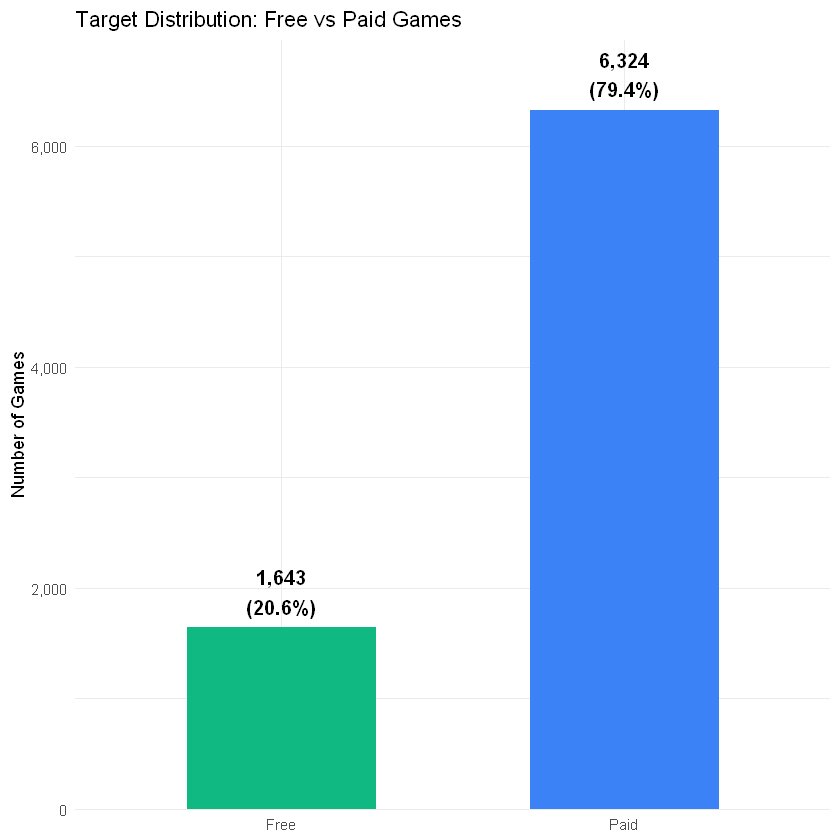

In [4]:

# ---- Target distribution ----
class_counts <- df_model |>
  count(is_free) |>
  mutate(
    pct = n / sum(n),
    label = paste0(comma(n), "
(", percent(pct, accuracy = 0.1), ")")
  )

ggplot(class_counts, aes(x = is_free, y = n, fill = is_free)) +
  geom_col(width = 0.55, show.legend = FALSE) +
  geom_text(aes(label = label), vjust = -0.3, size = 4.3, fontface = "bold") +
  scale_fill_manual(values = c("Free" = "#10B981", "Paid" = "#3B82F6")) +
  scale_y_continuous(labels = comma, expand = expansion(mult = c(0, 0.1))) +
  labs(
    title = "Target Distribution: Free vs Paid Games",
    x = NULL,
    y = "Number of Games"
  ) +
  theme_minimal()


The next graphs we look at describes the distribution of the numeric features. `n_categories` shows a clear right skew between both classes. Most games can only run on one operating system. Most games are released after the 2000s (coincides with Steam's release in 2003), and most games in the set do not have an age restriction. All these could have an impact on the model's performance since just by predicting the most popular class, it would likely have a high accuracy.

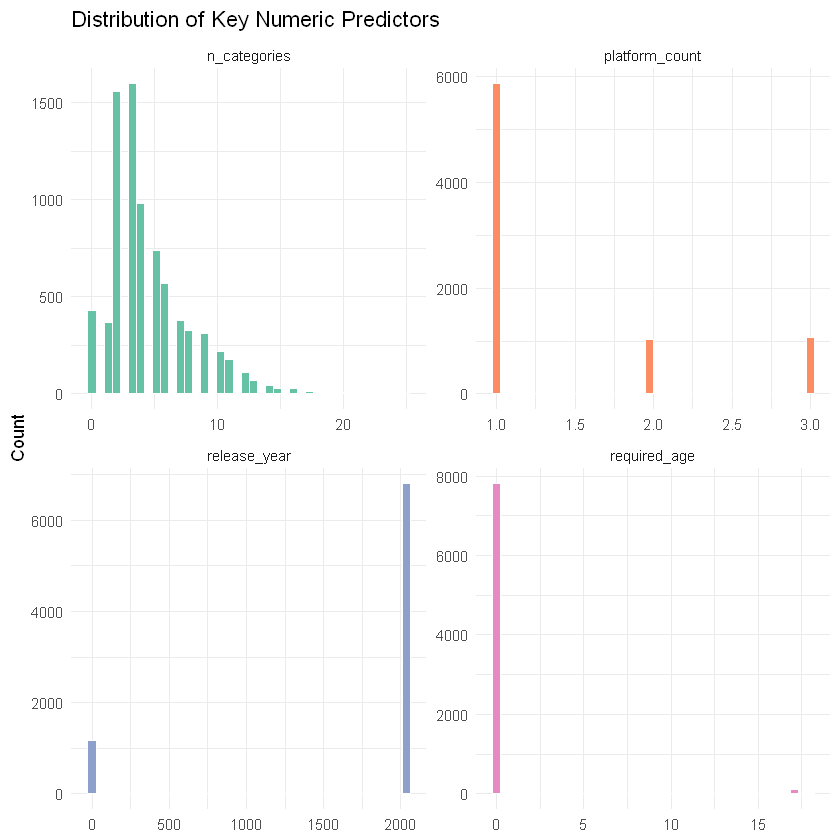

In [5]:

# ---- Numeric feature distributions ----
numeric_vars <- df_model |>
  select(required_age, release_year, platform_count, n_categories) |>
  pivot_longer(everything(), names_to = "variable", values_to = "value") |>
  drop_na()

ggplot(numeric_vars, aes(x = value, fill = variable)) +
  geom_histogram(bins = 40, color = "white", linewidth = 0.2, show.legend = FALSE) +
  facet_wrap(~ variable, scales = "free", ncol = 2) +
  scale_fill_brewer(palette = "Set2") +
  labs(
    title = "Distribution of Key Numeric Predictors",
    x = NULL,
    y = "Count"
  ) +
  theme_minimal()


Taking a more in-depth look into the release years, we see a left-skew in both categories. As Steam gains popularity over the years, more people are willing to publish their games on Steam, leading to a rise in games published in the years leading up to now (2026). Paid games make up the lion's share, implying that many game devs seek to capitalize on Steam's popularity and pursue profit from a vast ocean of customers.

Next, we look at the relationship between the categories a game has, and how many platforms it is available on. In our dataset, there are not enough games with 2 or 3 categories, as well as free games with one category, to determine anything. However, it appears that overall, most games regardless of number of categories appear to be able to run on two different operating systems.

The most interesting graph by far is the binary feature rates. We can see that paid games are both more likely to feature a demo or have DLC. This makes sense as a game with demos is essentially trying to pitch to a consumer why they should buy the game. It is the one of first marketing attempts a game makes when it wants to commit commercially. DLC (downloadable content) are a staple with paid games. Free games are not as likely to pursue any monetary gain, and creating DLCs are time-consuming and costly on resources. A paid game can usually recoup those costs through the upfront price of the game alone, which explains why DLC are more common among paid games.

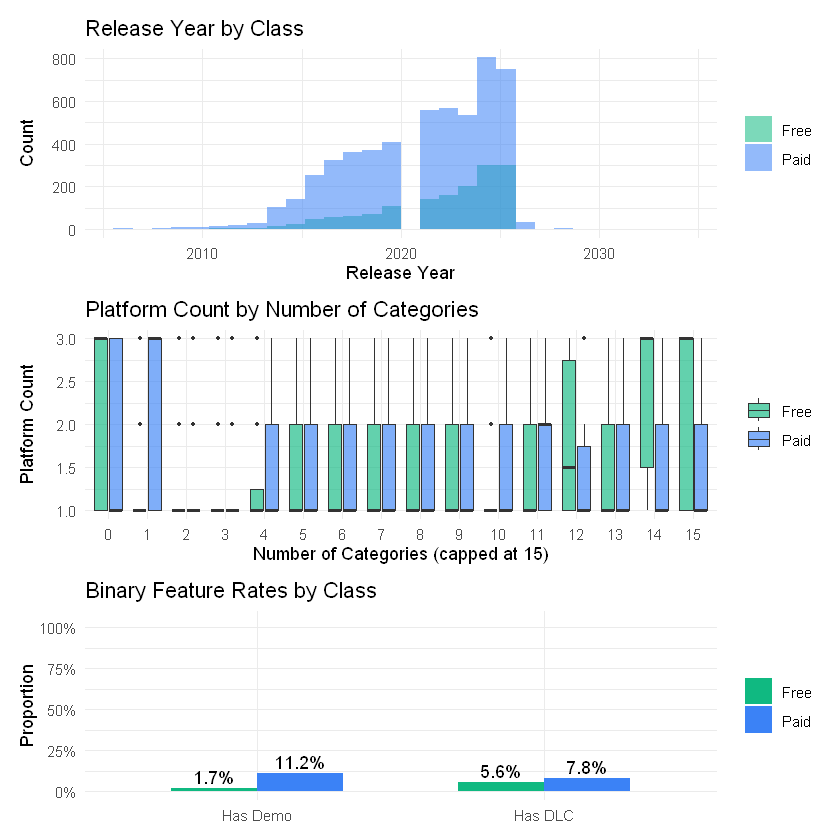

In [ ]:

# ---- Feature relationships ----
p1 <- ggplot(df_model |> filter(release_year > 0), aes(x = release_year, fill = is_free)) +
  geom_histogram(position = "identity", alpha = 0.55, bins = 30) +
  scale_fill_manual(values = c("Free" = "#10B981", "Paid" = "#3B82F6")) +
  labs(
    title = "Release Year by Class",
    x = "Release Year",
    y = "Count",
    fill = NULL
  ) +
  theme_minimal()

p2 <- df_model |>
  mutate(n_categories_capped = pmin(n_categories, 15L)) |>
  ggplot(aes(x = factor(n_categories_capped), y = platform_count, fill = is_free)) +
  geom_boxplot(alpha = 0.65, outlier.size = 0.7) +
  scale_fill_manual(values = c("Free" = "#10B981", "Paid" = "#3B82F6")) +
  labs(
    title = "Platform Count by Number of Categories",
    x = "Number of Categories (capped at 15)",
    y = "Platform Count",
    fill = NULL
  ) +
  theme_minimal()

p3 <- df_model |>
  group_by(is_free) |>
  summarise(
    `Has DLC` = mean(has_dlc),
    `Has Demo` = mean(has_demo),
    .groups = "drop"
  ) |>
  pivot_longer(-is_free, names_to = "feature", values_to = "pct") |>
  ggplot(aes(x = feature, y = pct, fill = is_free)) +
  geom_col(position = "dodge", width = 0.6) +
  geom_text(
    aes(label = percent(pct, accuracy = 0.1)),
    position = position_dodge(width = 0.6),
    vjust = -0.35,
    size = 3.8
  ) +
  scale_fill_manual(values = c("Free" = "#10B981", "Paid" = "#3B82F6")) +
  scale_y_continuous(labels = percent, limits = c(0, 1.05)) +
  labs(
    title = "Binary Feature Rates by Class",
    x = NULL,
    y = "Proportion",
    fill = NULL
  ) +
  theme_minimal()

p1 / p2 / p3


# 4. Categorical Feature Analysis
Categorical data is the next to be analyzed. The first graph shows that most games feature at least one category, and that both free and paid games are at similar rates.

The second graph shows the frequencies of the categories. The most common category is single-player, with family sharing decently close behind and Steam achievements following up at significantly lower rates. Looking at the rate of the categories alongside the frequencies of the free and paid categories paints an interesting picture. All the most common tags skew further towards the game being paid, which also gives us hints as to why there are significantly more paid games than free games. Demos are free, but demos are usually used in tandem with a paid game to attract potential buyers.

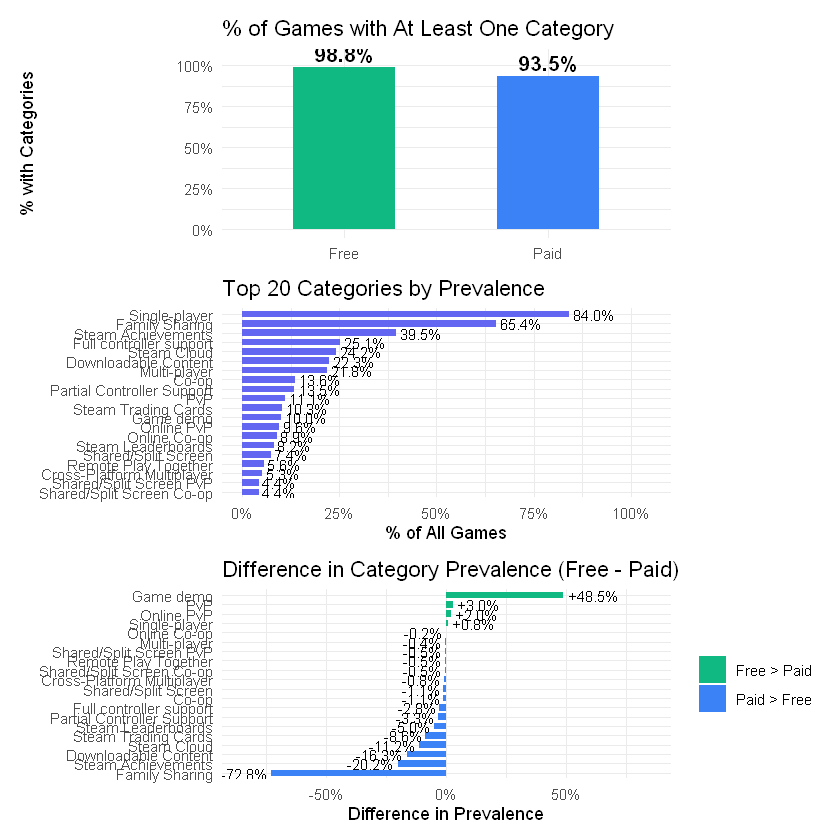

In [7]:

# ---- Category prevalence ----
cat_coverage <- df_model |>
  mutate(has_categories = n_categories > 0) |>
  group_by(is_free) |>
  summarise(pct = mean(has_categories), .groups = "drop")

p1 <- ggplot(cat_coverage, aes(x = is_free, y = pct, fill = is_free)) +
  geom_col(width = 0.5, show.legend = FALSE) +
  geom_text(aes(label = percent(pct, accuracy = 0.1)), vjust = -0.4, size = 4.4, fontface = "bold") +
  scale_fill_manual(values = c("Free" = "#10B981", "Paid" = "#3B82F6")) +
  scale_y_continuous(labels = percent, limits = c(0, 1.05)) +
  labs(title = "% of Games with At Least One Category", x = NULL, y = "% with Categories") +
  theme_minimal()

p2 <- all_cats |>
  count(category, sort = TRUE) |>
  slice_head(n = 20) |>
  mutate(pct = n / nrow(df_model)) |>
  ggplot(aes(x = reorder(category, pct), y = pct)) +
  geom_col(fill = "#6366F1", width = 0.7) +
  geom_text(aes(label = percent(pct, accuracy = 0.1)), hjust = -0.1, size = 3.2) +
  coord_flip() +
  scale_y_continuous(labels = percent, limits = c(0, 1.05)) +
  labs(title = "Top 20 Categories by Prevalence", x = NULL, y = "% of All Games") +
  theme_minimal()

cat_prev <- flat_data |>
  select(game_id, is_free, category_list) |>
  unnest(category_list) |>
  rename(category = category_list) |>
  filter(category %in% top_categories) |>
  count(is_free, category) |>
  left_join(df_model |> count(is_free, name = "group_total"), by = "is_free") |>
  mutate(pct = n / group_total)

cat_diff <- cat_prev |>
  select(is_free, category, pct) |>
  pivot_wider(names_from = is_free, values_from = pct, values_fill = 0) |>
  mutate(
    diff = Free - Paid,
    direction = if_else(diff > 0, "Free > Paid", "Paid > Free")
  ) |>
  arrange(desc(abs(diff)))

p3 <- ggplot(cat_diff, aes(x = reorder(category, diff), y = diff, fill = direction)) +
  geom_col(width = 0.7) +
  geom_text(
    aes(label = paste0(if_else(diff > 0, "+", ""), percent(diff, accuracy = 0.1))),
    hjust = if_else(cat_diff$diff > 0, -0.1, 1.1),
    size = 3.1
  ) +
  coord_flip() +
  scale_fill_manual(values = c("Free > Paid" = "#10B981", "Paid > Free" = "#3B82F6")) +
  scale_y_continuous(labels = percent, limits = c(-0.85, 0.85)) +
  labs(
    title = "Difference in Category Prevalence (Free - Paid)",
    x = NULL,
    y = "Difference in Prevalence",
    fill = NULL
  ) +
  theme_minimal()

p1 / p2 / p3


# 5. Modeling Pipeline
When beginning machine learning, we first want to split the data into the training and testing split. For our data, we choose to place 80% of the data into the training set and leaving the other 20% in the testing set.

Next, we pick the features we think are most relevant to the problem. We store these features into a variable for easier access to use later in the model. Our first instance of using it is to select the appropriate columns in the training and testing sets.

And as any machine learning analysis goes, we begin with a baseline model to check whether our next model will perform significantly better. We use the majority-class baseline (dummy classifier essentially) to get the baseline accuracy, which is 79.4%. This is the exact same as the rate of paid in our classes, which is further proof that our data is imbalanced.

In [8]:

# ---- Train/test split ----
set.seed(123)
train_idx <- createDataPartition(df_model$is_free, p = 0.80, list = FALSE)
train_df <- df_model[train_idx, ]
test_df  <- df_model[-train_idx, ]

cat("Training rows:", nrow(train_df), "
")
cat("Test rows:", nrow(test_df), "
")

# Keep predictors that are available before launch-time pricing decision
predictor_names <- c(
  "required_age", "release_year", "game_type",
  "windows_support", "mac_support", "linux_support",
  "platform_count", "has_dlc", "has_demo", "n_categories",
  grep("^cat_", names(df_model), value = TRUE)
)

train_model <- train_df |>
  select(is_free, all_of(predictor_names))

test_model <- test_df |>
  select(is_free, all_of(predictor_names))

# Majority-class baseline for comparison
baseline_class <- train_model |>
  count(is_free, sort = TRUE) |>
  slice(1) |>
  pull(is_free) |>
  as.character()

baseline_pred <- factor(
  rep(baseline_class, nrow(test_model)),
  levels = levels(test_model$is_free)
)

baseline_cm <- confusionMatrix(baseline_pred, test_model$is_free, positive = "Free")
baseline_accuracy <- unname(baseline_cm$overall["Accuracy"])

baseline_accuracy


Training rows: 6375 
Test rows: 1592 


[1] 0.7939698

Next, we picked logistic regression to be our model of choice. It is easy to deploy, tune hyperparameters for, and generally straightforward to interpret. Obviously the base model is not sufficient to test, so we want to tune it first to get a good model to work with. We initiallize 5 cross-validation folds. This will be saved for the training aspect.

Then, we create the model's formula. The `predictor_names` variable comes into play when creating the formula for the model.

We put the two variables together into the logistic regression model created by the `caret` package. It allows for a fast deployment for classification (and regression) models. From the model, we get some good results. Even without preprocessing and only a 5-fold cross-validation, it returns high ROC, which implies a very strong model. The model is much stronger at identifying false positives (saying the game is free but it is actually paid) than false negatives (saying the game is paid but it is actually free), which in our case is a not good thing since we are more interested in finding actually free games.

In [9]:

# ---- Cross-validated logistic regression ----
ctrl <- trainControl(
  method = "cv",
  number = 5,
  classProbs = TRUE,
  summaryFunction = twoClassSummary,
  savePredictions = "final"
)

model_formula <- as.formula(
  paste("is_free ~", paste(predictor_names, collapse = " + "))
)

set.seed(123)
fit_glm <- caret::train(
  model_formula,
  data = train_model,
  method = "glm",
  family = binomial(),
  metric = "ROC",
  trControl = ctrl
)

fit_glm


Generalized Linear Model 

6375 samples
  30 predictor
   2 classes: 'Free', 'Paid' 

No pre-processing
Resampling: Cross-Validated (5 fold) 
Summary of sample sizes: 5100, 5100, 5100, 5100, 5100 
Resampling results:

  ROC        Sens       Spec     
  0.9252983  0.8410646  0.9887352


# 6. Held-Out Test Evaluation
With our model tuned, it is ready to be deployed on the test set. We test the fitted model on our test set and isolate the predictions. Here we use soft predictions, so if the model is more confident in one class, we set the "final" prediction to be the more confident class.

We also create several explanatory visualizations, including a confusion matrix, a table that shows the model's classification metrics on all test set, and the features the model deems as most important.

Our first table is the classification metrics for the model:
* The model performs 0.16 better than the baseline model.
* Sensitivity (recall) is quite high at 0.838, but is lower than the specificity. This is unfortunate since we are more interested in games that are actually free.
* Specificity (precision) is extremely high, bordering on perfect. While the high score is nice to see, it would have been better to trade some off to increase sensitivity.
* Balanced accuracy is better than recall, implying that the "average recall for each class" (da Silva, 2024) is quite good with this model.
* High ROC is always a good sign, although looking at the ROC graph is a much better way to see how the model does in terms of trading off sensitivity for specificity.

In [10]:

# ---- Test predictions ----
prob_free <- predict(fit_glm, newdata = test_model, type = "prob")$Free
pred_class <- factor(
  ifelse(prob_free >= 0.5, "Free", "Paid"),
  levels = levels(test_model$is_free)
)

cm <- confusionMatrix(pred_class, test_model$is_free, positive = "Free")
roc_obj <- pROC::roc(
  response = test_model$is_free,
  predictor = prob_free,
  levels = c("Paid", "Free"),
  direction = "<"
)

eval_tbl <- tibble(
  metric = c(
    "Baseline Accuracy",
    "Model Accuracy",
    "Sensitivity (Recall for Free)",
    "Specificity",
    "Balanced Accuracy",
    "ROC AUC"
  ),
  value = c(
    baseline_accuracy,
    unname(cm$overall["Accuracy"]),
    unname(cm$byClass["Sensitivity"]),
    unname(cm$byClass["Specificity"]),
    unname(cm$byClass["Balanced Accuracy"]),
    as.numeric(pROC::auc(roc_obj))
  )
)

eval_tbl |>
  mutate(value = round(value, 4))


metric,value
<chr>,<dbl>
Baseline Accuracy,0.7940
Model Accuracy,0.9585
Sensitivity (Recall for Free),0.8384
Specificity,0.9897
Balanced Accuracy,0.9141
ROC AUC,0.9232


The confusion matrix provides the raw numbers used to calculate most of the classification metrics. It also provides some statistical analysis of the accuracy and rehashes the classification metrics.

It also shows Cohen's Kappa, which with its high value, suggests that the model would still perform well even with kappa "the agreement that could occur simply due to the majority class" (Cadili et al., 2025).

In [11]:

# ---- Confusion matrix ----
cm


Confusion Matrix and Statistics

          Reference
Prediction Free Paid
      Free  275   13
      Paid   53 1251
                                          
               Accuracy : 0.9585          
                 95% CI : (0.9476, 0.9678)
    No Information Rate : 0.794           
    P-Value [Acc > NIR] : < 2.2e-16       
                                          
                  Kappa : 0.8673          
                                          
 Mcnemar's Test P-Value : 1.582e-06       
                                          
            Sensitivity : 0.8384          
            Specificity : 0.9897          
         Pos Pred Value : 0.9549          
         Neg Pred Value : 0.9594          
             Prevalence : 0.2060          
         Detection Rate : 0.1727          
   Detection Prevalence : 0.1809          
      Balanced Accuracy : 0.9141          
                                          
       'Positive' Class : Free            
                        

This is a visualization of the ROC curve. The top left would imply a perfect model, and while our model gets decently close, it isn't 100% perfect.

Test AUC: 0.9232 


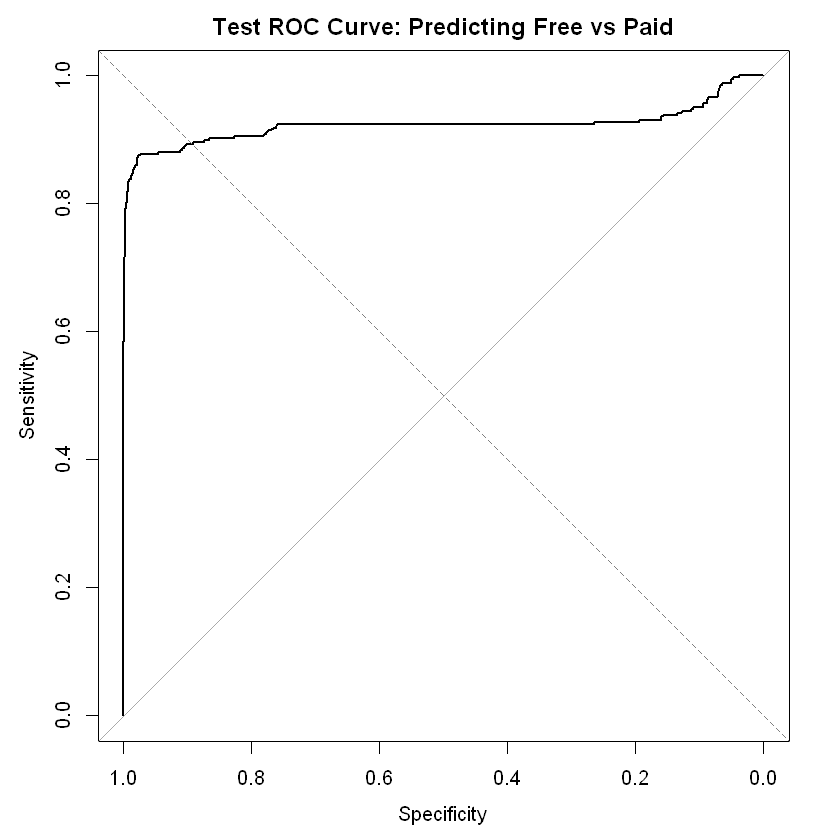

In [12]:

# ---- ROC curve ----
plot(roc_obj, main = "Test ROC Curve: Predicting Free vs Paid")
abline(a = 0, b = 1, lty = 2, col = "gray50")
cat("Test AUC:", round(as.numeric(pROC::auc(roc_obj)), 4), "
")


This is an unordered table of the coefficients used to determine the importance of different features. Below this is the ranking for the most important features. It seems contrary to our intuition of what could make a game free, since it looked like family sharing games were more likely to be paid.

In [13]:

# ---- Model interpretation ----
coef_tbl <- summary(fit_glm$finalModel)$coefficients |>
  as.data.frame() |>
  rownames_to_column("term") |>
  as_tibble() |>
  arrange(desc(abs(Estimate)))

head(coef_tbl, 15)


term,Estimate,Std. Error,z value,Pr(>|z|)
<chr>,<dbl>,<dbl>,<dbl>,<dbl>
game_typeseries,-39.2464419,6514.7464763,-6.024247e-03,9.951934e-01
game_typedemo,-32.9358480,4618.7023108,-7.130974e-03,9.943104e-01
(Intercept),32.4997756,6253.9068358,5.196716e-03,9.958536e-01
game_typemod,-31.8474246,5436.2745498,-5.858318e-03,9.953258e-01
windows_supportTRUE,-16.6597735,4223.6175543,-3.944432e-03,9.968528e-01
cat_downloadable_contentTRUE,-15.8763998,2170.3304203,-7.315199e-03,9.941634e-01
game_typegame,-14.8433578,4612.2018067,-3.218280e-03,9.974322e-01
game_typeepisode,-14.6177833,4612.2018282,-3.169372e-03,9.974712e-01
game_typevideo,-13.4771500,4612.2018761,-2.922064e-03,9.976685e-01


In [14]:

# caret variable importance
varImp(fit_glm)


glm variable importance

  only 20 most important variables shown (out of 35)

                                   Overall
cat_family_sharingTRUE            100.0000
cat_single_playerTRUE              45.4752
cat_steam_leaderboardsTRUE         12.3225
cat_multi_playerTRUE               12.0377
has_demoTRUE                        9.5087
linux_supportTRUE                   7.8566
has_dlcTRUE                         7.4096
cat_pv_pTRUE                        5.1941
cat_steam_cloudTRUE                 4.6945
release_year                        3.7439
cat_shared_split_screenTRUE         3.2902
cat_steam_trading_cardsTRUE         3.2237
cat_co_opTRUE                       3.0638
cat_shared_split_screen_co_opTRUE   2.7718
mac_supportTRUE                     2.1588
cat_shared_split_screen_pv_pTRUE    2.0513
cat_steam_achievementsTRUE          1.8518
n_categories                        1.5958
cat_full_controller_supportTRUE     1.1283
cat_remote_play_togetherTRUE        0.7597


# 7. Conclusion

From this analysis, we found that the five highest predictors for a game being free is if the game has family sharing, it is singleplayer, if it has Steam leaderboards, if it is multiplayer, and if it is a demo. For the most part we did not expect these categories, aside from demo and singleplayer, to be the most deterministic as to whether a game would be free. In our categorical analysis, it showed that significantly more paid games featured family sharing. Multiplayer games are usually split into many different types, like MOBAs, MMORPGs, etc., but even then, so it somewhat made sense that a multiplayer game would need to be free to attract crowds to play it.

At the large scale, it would be interesting to apply what we have learned from this topic to predict even larger patterns. With a refined and well-trained model, we could potentially predict beyond whether a game would be free or not. It could predict trends in consumption patterns, gaming industry movements, and even more.

### Next Questions
* What sorts of family games are free, and what types are paid?
* If we had defined multiplayer games into more specific subcategories, could we see a difference between free multiplayers and paid multiplayers?
* Could demos be considered noise in our data set?


## References
Cadili, R., Fyson, H., & Widmann, M. (2015, December 16.) *What is Cohen’s Kappa? How and When to Use It (Plus Common Pitfalls to Avoid)*. Knime. [https://www.knime.com/blog/cohens-kappa-an-overview](https://www.knime.com/blog/cohens-kappa-an-overview) <br>
de Silva, Caina Max Couto. (2024, September 18). *A Data Scientist’s Guide to Balanced Accuracy*. Train in Data. [https://www.blog.trainindata.com/a-data-scientists-guide-to-balanced-accuracy/](https://www.blog.trainindata.com/a-data-scientists-guide-to-balanced-accuracy/) <br>
Steam. (n.d.). *Charts Overview*. [https://store.steampowered.com/charts/](https://store.steampowered.com/charts/) <br>
Statista Research Department. (2026, February). *Number of games released on Steam worldwide from 2004 to 2025*. Statista. [https://www.statista.com/statistics/552623/number-games-released-steam/?srsltid=AfmBOooX57cVGK2KPEUJxjsV3EiS3r_v5_kF0gksFdCGOZQ0y1zv0kzT](https://www.statista.com/statistics/552623/number-games-released-steam/?srsltid=AfmBOooX57cVGK2KPEUJxjsV3EiS3r_v5_kF0gksFdCGOZQ0y1zv0kzT)